# 🧠 MNIST VisionAI

### 🚀 Highlights
- Auto-download MNIST dataset (from TensorFlow Keras repository)
- Data augmentation + normalization
- CNN model with dropout and batch training
- EarlyStopping + ReduceLROnPlateau
- Evaluation with confusion matrix & classification report
- Grad‑CAM for explainability
- Model export (H5, SavedModel, TensorFlow Lite)
- Single-image prediction demo

## Installing & Importing Packages

In [43]:
!pip install tensorflow matplotlib scikit-learn seaborn -q

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow:", tf.__version__)
device_name = tf.config.list_physical_devices('GPU')
print("GPU available:", bool(device_name))

TensorFlow: 2.19.0
GPU available: False


## Loading MNIST Dataset

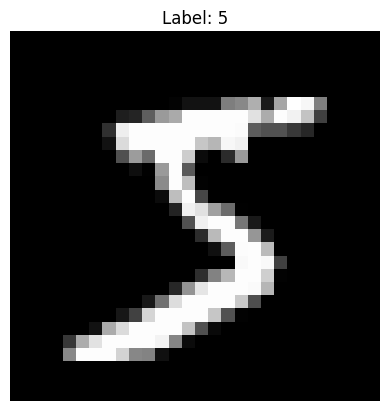

In [51]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = (x_train / 255.0).astype("float32")[..., None]  # (N, 28, 28, 1)
x_test  = (x_test  / 255.0).astype("float32")[..., None]

plt.imshow(x_train[0].squeeze(), cmap='gray')
plt.title(f"Label: {y_train[0]}"); plt.axis('off'); plt.show()

## Data Augmentation

In [52]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=10, width_shift_range=0.1, height_shift_range=0.1, zoom_range=0.1
)
datagen.fit(x_train)


## Building CNN Model

In [53]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=(28,28,1)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),

    layers.Conv2D(64, 3, activation='relu'),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 197,482 (771.41 KB)

 Trainable params: 197,482 (771.41 KB)

 Non-trainable params: 0 (0.00 B)

## Training With EarlyStopping & LR Scheduler

In [54]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1),
]

history = model.fit(
    datagen.flow(x_train, y_train, batch_size=128),
    epochs=15,
    validation_data=(x_test, y_test),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


469/469 ━━━━━━━━━━━━━━━━━━━━ 174s 363ms/step - accuracy: 0.6732 - loss: 0.9580 - val_accuracy: 0.9842 - val_loss: 0.0445 - learning_rate: 0.0010
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 157s 335ms/step - accuracy: 0.9456 - loss: 0.1798 - val_accuracy: 0.9887 - val_loss: 0.0338 - learning_rate: 0.0010
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 158s 336ms/step - accuracy: 0.9609 - loss: 0.1313 - val_accuracy: 0.9931 - val_loss: 0.0202 - learning_rate: 0.0010
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 153s 326ms/step - accuracy: 0.9700 - loss: 0.0999 - val_accuracy: 0.9934 - val_loss: 0.0183 - learning_rate: 0.0010
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 158s 336ms/step - accuracy: 0.9732 - loss: 0.0915 - val_accuracy: 0.9944 - val_loss: 0.0181 - learning_rate: 0.0010
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 203s 338ms/step - accuracy: 0.9777 - loss: 0.0751 - val_accuracy: 0.9940 - val_loss: 0.0174 - learning_rate: 0.0010
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 157s 334ms/step - accuracy: 0.9792 

## Evaluate Performance

✅ Test Accuracy: 0.9954
              precision    recall  f1-score   support

           0     0.9980    0.9990    0.9985       980
           1     0.9965    0.9947    0.9956      1135
           2     0.9942    0.9952    0.9947      1032
           3     0.9892    1.0000    0.9946      1010
           4     0.9969    0.9959    0.9964       982
           5     0.9989    0.9922    0.9955       892
           6     0.9948    0.9948    0.9948       958
           7     0.9932    0.9942    0.9937      1028
           8     0.9959    0.9949    0.9954       974
           9     0.9970    0.9931    0.9950      1009

    accuracy                         0.9954     10000
   macro avg     0.9955    0.9954    0.9954     10000
weighted avg     0.9954    0.9954    0.9954     10000



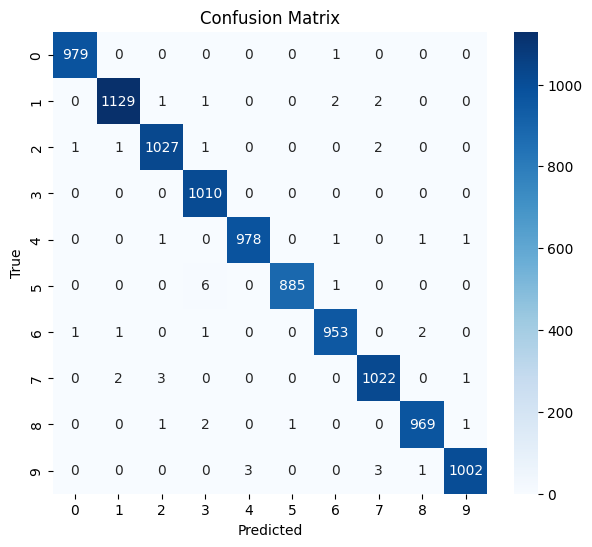

In [55]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"✅ Test Accuracy: {test_acc:.4f}")

y_pred = model.predict(x_test, verbose=0).argmax(axis=1)
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix'); plt.show()

# GRAD-CAM Explainability

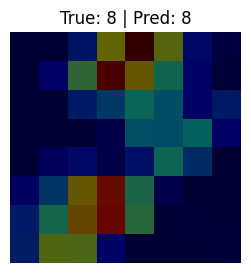

In [61]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Ensure float32 input
x_test = x_test.astype("float32")

# 1) Rewire your trained Sequential model into a Functional graph,
#    capturing the last Conv2D feature maps on the way.
inp = tf.keras.Input(shape=(28, 28, 1))
x = inp
last_conv_feat = None

for lyr in model.layers:
    x = lyr(x)  # reuse the SAME layer objects -> same weights
    if isinstance(lyr, tf.keras.layers.Conv2D):
        last_conv_feat = x

if last_conv_feat is None:
    raise ValueError("No Conv2D layer found in the model.")

cam_model = tf.keras.Model(inputs=inp, outputs=[last_conv_feat, x])

# 2) One-image Grad-CAM
idx = 1234
img = x_test[idx:idx+1]
pred = int(np.argmax(model.predict(img, verbose=0)))

with tf.GradientTape() as tape:
    conv_maps, logits = cam_model(img, training=False)  # conv_maps: (1,H,W,C)
    probs = tf.nn.softmax(logits, axis=-1)
    loss = probs[:, pred]

grads = tape.gradient(loss, conv_maps)                 # (1,H,W,C)
pooled = tf.reduce_mean(grads, axis=(0, 1, 2))         # (C,)
heat  = tf.reduce_sum(conv_maps[0] * pooled, axis=-1)  # (H,W)
heat  = tf.nn.relu(heat)
heat  = tf.math.divide_no_nan(heat, tf.reduce_max(heat))

# 3) Plot
plt.figure(figsize=(5,3))
plt.imshow(img[0].squeeze(), cmap='gray')
plt.imshow(heat.numpy(), cmap='jet', alpha=0.4)
plt.title(f"True: {int(y_test[idx])} | Pred: {pred}")
plt.axis('off'); plt.show()



## Saving & Exporting Model

In [63]:
model.save("mnist_tf_model.h5")
model.export("mnist_saved_model")
print("✅ Saved as H5 and SavedModel formats.")

Saved artifact at 'mnist_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor_91')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  136567590901072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136567590896272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136567590901840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136568635707792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136568635704144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136568635718736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136568635719504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136568635705104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136568635703952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136568635705296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13656863570

## Single-Image Inference Demo

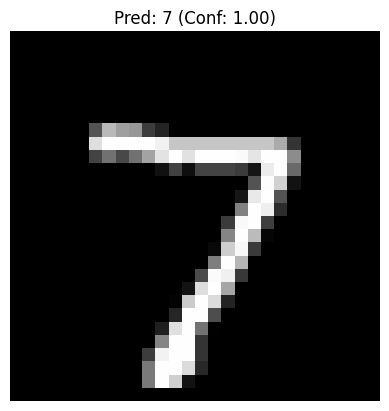

In [67]:
def _prep(img):
    x = img
    # ensure float32
    x = x.astype("float32")
    # scale if needed
    if x.max() > 1.0:
        x = x / 255.0
    # add channel dim only if it's missing
    if x.ndim == 2:
        x = x[..., None]            # (H,W,1)
    elif x.ndim == 3 and x.shape[-1] == 1:
        pass                        # already ok
    else:
        raise ValueError(f"Expected (H,W) or (H,W,1), got {x.shape}")
    # add batch dim
    x = x[None, ...]                # (1,H,W,1)
    return x

def predict_single(img):
    x = _prep(img)
    probs = model.predict(x, verbose=0)[0]   # (10,)
    return int(np.argmax(probs)), float(np.max(probs))

# Example use:
plt.imshow(x_test[0].squeeze(), cmap='gray'); plt.axis('off')
pred, conf = predict_single(x_test[0])  # works whether x_test[0] is (28,28) or (28,28,1)
plt.title(f"Pred: {pred} (Conf: {conf:.2f})"); plt.show()
